In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import ants
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [ ]:
import marimo as mo
os.chdir(mo.notebook_dir()) #Jupyterlab-like, change path to where the notebook is, all paths relative to this

In [ ]:
import deepcor

In [ ]:
#deepcor.utils.check_gpu_and_speedup(tensor_size=(1000,1000), n_iter=100)

In [ ]:
# ModelConfig: Configure the model architecture
model_config = deepcor.ModelConfig(
    latent_dims=(8, 8),  # (shared dim, specific dim)
    beta=0.01,           # KLD loss weight
    gamma=0.0,           # TC loss weight
    delta=0.0,           # RONI zero constraint weight
    scale_MSE_GM=1e3,    # Gray matter reconstruction loss scale
    scale_MSE_CF=1e3,    # Non-gray matter reconstruction loss scale
    scale_MSE_FG=0.0,    # Foreground reconstruction loss scale
    do_disentangle=True  # Enable disentanglement
)


# TrainingConfig: Configure training parameters
training_config = deepcor.TrainingConfig(
    n_epochs=100,
    batch_size=256,
    learning_rate=0.001,
    optimizer='adamw',
    betas=(0.9, 0.999),
    eps=1e-08,
    max_grad_norm=5.0,
    n_repetitions=20  # Number of ensemble repetitions
)


# DataConfig: Configure data preprocessing
data_config = deepcor.DataConfig(
    n_dummy_scans=0,
    apply_censoring=False,
    censoring_threshold=0.0,
    confound_columns=['X', 'Y', 'Z', 'RotX', 'RotY', 'RotZ']
)

# Create a complete configuration
config = deepcor.DeepCorConfig(
    model=model_config,
    training=training_config,
    data=data_config
)


print(model_config);print('\n')
print(training_config);print('\n')
print(data_config);print('\n')
print(config);print('\n')

ModelConfig(latent_dims=(8, 8), hidden_dims=None, beta=0.01, gamma=0.0, delta=0.0, scale_MSE_GM=1000.0, scale_MSE_CF=1000.0, scale_MSE_FG=0.0, do_disentangle=True)


TrainingConfig(n_epochs=100, batch_size=256, learning_rate=0.001, optimizer='adamw', betas=(0.9, 0.999), eps=1e-08, max_grad_norm=5.0, n_repetitions=20)


DataConfig(n_dummy_scans=0, apply_censoring=False, censoring_threshold=0.5, also_nearby_voxels=True, confound_columns=['X', 'Y', 'Z', 'RotX', 'RotY', 'RotZ'])


DeepCorConfig(model=ModelConfig(latent_dims=(8, 8), hidden_dims=None, beta=0.01, gamma=0.0, delta=0.0, scale_MSE_GM=1000.0, scale_MSE_CF=1000.0, scale_MSE_FG=0.0, do_disentangle=True), training=TrainingConfig(n_epochs=100, batch_size=256, learning_rate=0.001, optimizer='adamw', betas=(0.9, 0.999), eps=1e-08, max_grad_norm=5.0, n_repetitions=20), data=DataConfig(n_dummy_scans=0, apply_censoring=False, censoring_threshold=0.5, also_nearby_voxels=True, confound_columns=['X', 'Y', 'Z', 'RotX', 'RotY', 'RotZ']))




In [ ]:
# Define Data Paths
# Cell Tagged parameters for papermill looping

bids_path = '../Data/fMRI-Data/studyforrest-fmriprep/'

subs = [sub for sub in os.listdir(os.path.join(bids_path)) if sub.startswith('sub-')]
subs.sort()

session = 'ses-localizer'
task = 'objectcategories'
space = 'MNI152NLin2009cAsym'

s = 0
r = 1
analysis_name = 'test-advanced'

In [ ]:
sub_id = subs[s]
run = str(r)

print(sub_id)
print(run)
print(analysis_name)

sub-01
1
test-advanced


In [ ]:
base = os.path.join(bids_path,sub_id,session)

# EPI
epi_path = os.path.join(base,'func',f'{sub_id}_{session}_task-{task}_run-{run}_bold_space-{space}_preproc.nii.gz')

# Confounds
confounds_path = os.path.join(base,'func',f'{sub_id}_{session}_task-{task}_run-{run}_bold_confounds.tsv')

gm_mask_path = os.path.join(bids_path,'mask_roi.nii')
cf_mask_path = os.path.join(bids_path,'mask_roni.nii')

assert os.path.exists(epi_path), 'epi_path does not exist'
assert os.path.exists(confounds_path), 'confounds_path does not exist'
assert os.path.exists(gm_mask_path), 'gm_mask_path does not exist'
assert os.path.exists(cf_mask_path), 'cf_mask_path does not exist'

os.makedirs(os.path.join('../Data/DeepCor-Outputs',analysis_name), exist_ok=True)
output_dir = os.path.join('../Data/DeepCor-Outputs',analysis_name,f'DeepCor-Forrest-{sub_id}-{task}-{run}-cvae_v1')
deepcor.utils.io.safe_mkdir(output_dir)

print("EPI:", epi_path)
print("Confounds:", confounds_path)
print("output_dir:", output_dir)

EPI: ../Data/fMRI-Data/studyforrest-fmriprep/sub-01/ses-localizer/func/sub-01_ses-localizer_task-objectcategories_run-1_bold_space-MNI152NLin2009cAsym_preproc.nii.gz
Confounds: ../Data/fMRI-Data/studyforrest-fmriprep/sub-01/ses-localizer/func/sub-01_ses-localizer_task-objectcategories_run-1_bold_confounds.tsv
output_dir: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-sub-01-objectcategories-1-cvae_v1


In [ ]:
epi = ants.image_read(epi_path)
df_conf = pd.read_csv(confounds_path, sep='\t') # Use tab separator
gm = ants.image_read(gm_mask_path)
cf = ants.image_read(cf_mask_path)

obs_list, noi_list, gm, cf = deepcor.data.get_obs_noi_list(epi, gm, cf)

obs_list.shape: (41116, 156)
noi_list.shape: (9092, 156)
upsampling noi_list_coords
obs_list.shape: (41116, 156)
noi_list.shape: (41116, 156)


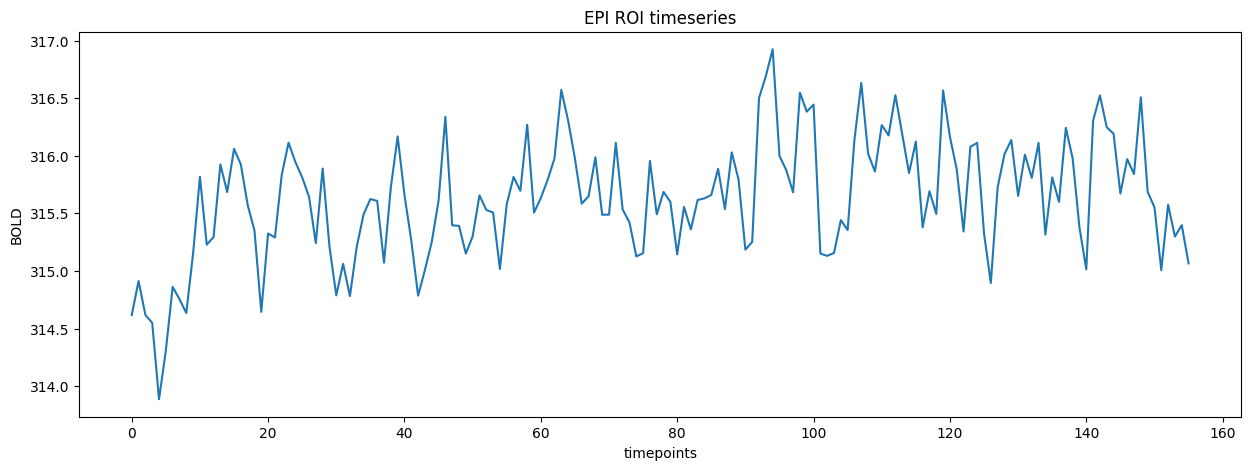

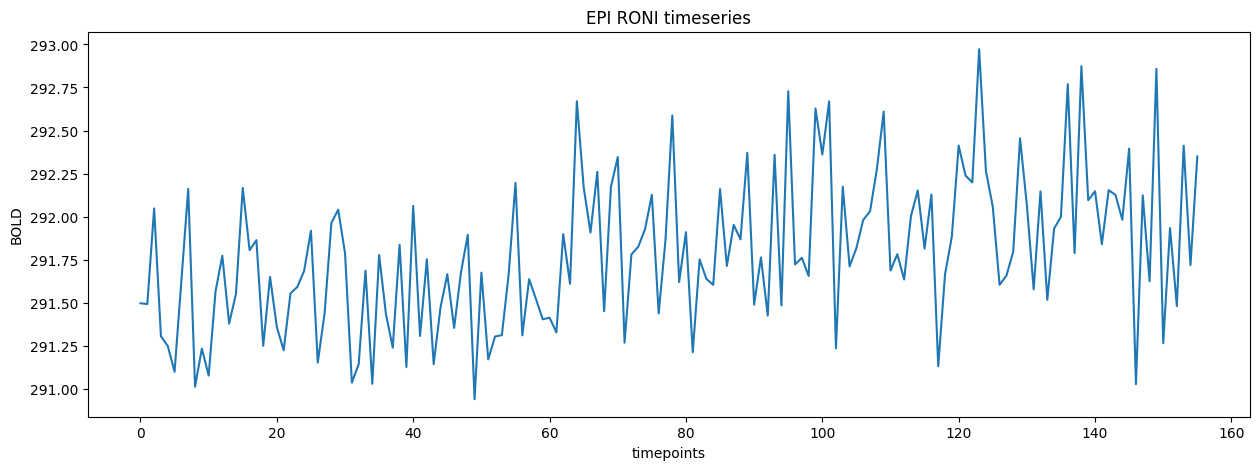

In [ ]:
deepcor.data.plot_timeseries(epi,gm,cf)

In [ ]:
# Create DataLoader 
train_dataset = deepcor.data.TrainDataset(obs_list, noi_list)
train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=config.training.batch_size, 
    shuffle=True, 
    drop_last=True
)

In [ ]:
in_dim = obs_list.shape[-1]
# Initialize Model
# We pass the Prepared confounds tensor here
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = deepcor.models.CVAE_V1(in_channels=1,in_dim=in_dim,latent_dim=8)
model = model.to(device)
print("Model initialized and moved to device")

Model initialized and moved to device


In [ ]:
config.training.n_epochs = 10

In [ ]:
# Initialize Trainer
trainer = deepcor.training.Trainer(
    model,
    device=device,
    optimizer_type=config.training.optimizer,
    lr=config.training.learning_rate,
    betas=config.training.betas,
    eps=config.training.eps,
    max_grad_norm=config.training.max_grad_norm
)
print("Trainer initialized")

Trainer initialized


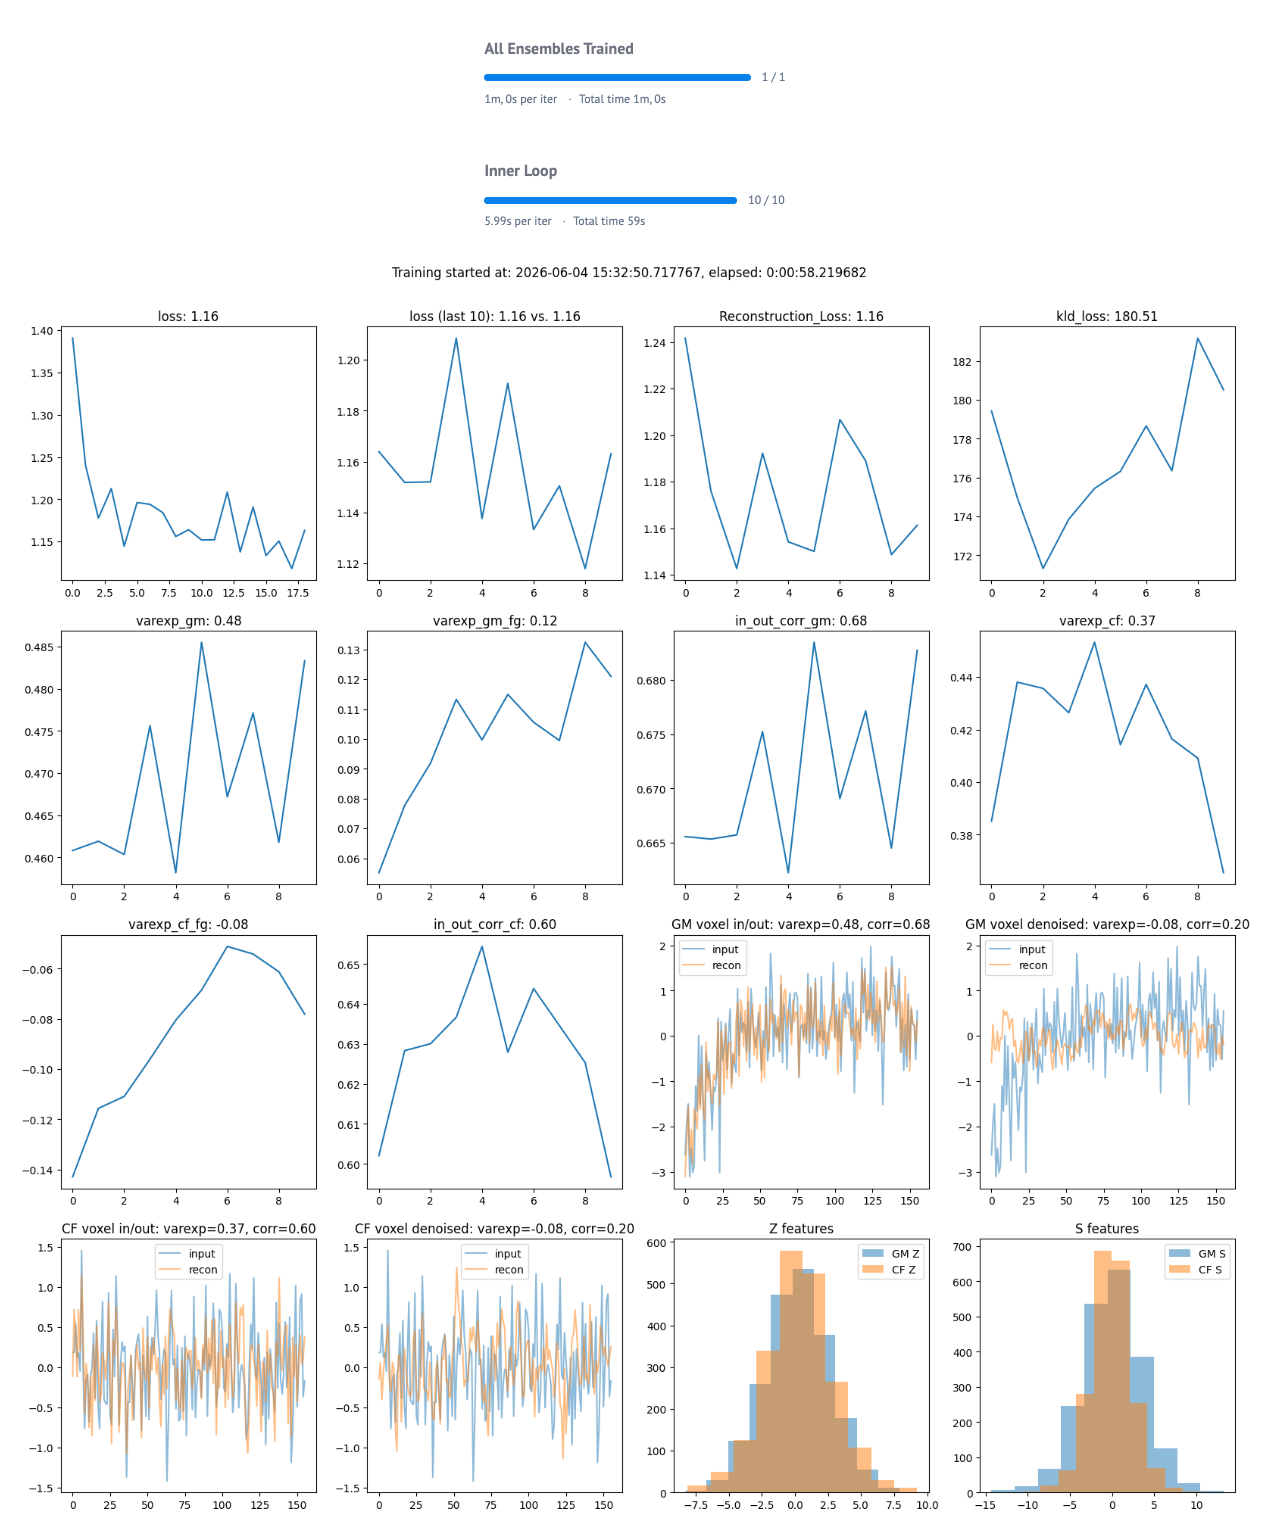

In [ ]:
n_ensebles = 1
for ensemble in mo.status.progress_bar(range(n_ensebles),title='Outer Loop',completion_title='All Ensembles Trained', show_eta=True):
    track = deepcor.visualization.init_track('V1')
    loss_history = []
    for epoch in mo.status.progress_bar(range(config.training.n_epochs),show_eta=True,title='Inner Loop',remove_on_exit=False):
        # Train one epoch
        avg_loss = trainer.train_epoch(train_loader)
        loss_history.append(avg_loss)

        deepcor.visualization.update_track(track,train_loader,model)
        track['loss'] = loss_history

        fig = deepcor.visualization.show_dahsboard_v1_marimo(track)
        #mo.output.replace(fig)   # replace previous plot with the new one
        mo.output.replace_at_index(fig,2)
        #plt.close(fig)           # avoid duplicate/static matplotlib display

    # Save outputs
    #print("Saving model and results...")
    # Save checkpoint
    trainer.save_checkpoint(
        os.path.join(output_dir, f'model_final_ens{ensemble}.pt'), 
        config.training.n_epochs, 
        avg_loss)

    # Save track
    deepcor.visualization.save_track(os.path.join(output_dir, f'track_ens{ensemble}.pickle'), track)